## **Import Required Libraries**

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

## **Load Dataset**

In [8]:
df = pd.read_csv("Advertising.csv")

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## **Data Exploration**


In [23]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


,0
Unnamed: 0,0
TV,0
Radio,0
Newspaper,0
Sales,0


**Removing Unnamed column**

In [25]:
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

## **Data Visualization**
**Sales Distribution**

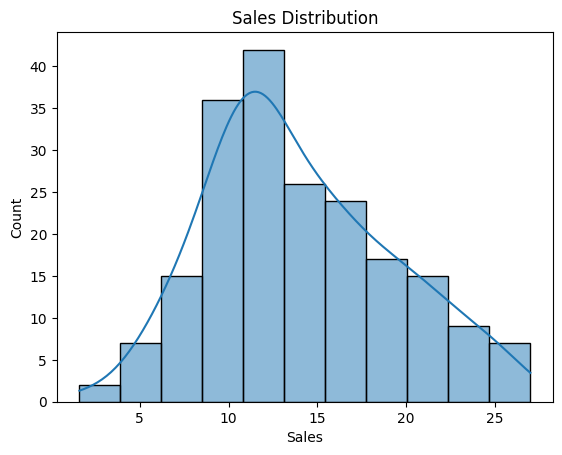

In [26]:
sns.histplot(df["Sales"], kde=True)
plt.title("Sales Distribution")
plt.show()

**Relationship Between Advertising and Sales**

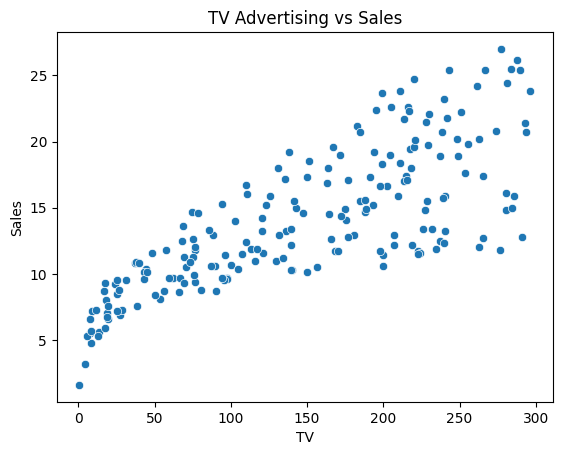

In [27]:
sns.scatterplot(x="TV", y="Sales", data=df)
plt.title("TV Advertising vs Sales")
plt.show()

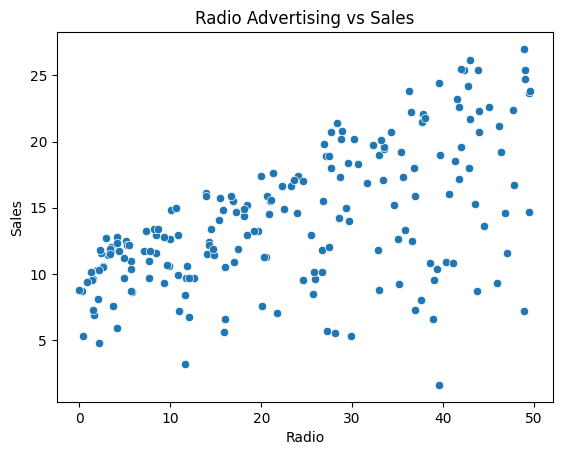

In [28]:
sns.scatterplot(x="Radio", y="Sales", data=df)
plt.title("Radio Advertising vs Sales")
plt.show()

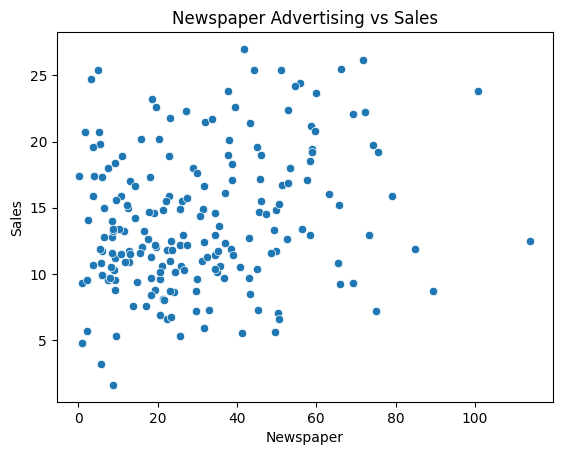

In [29]:
sns.scatterplot(x="Newspaper", y="Sales", data=df)
plt.title("Newspaper Advertising vs Sales")
plt.show()

## **Correlation Heatmap**

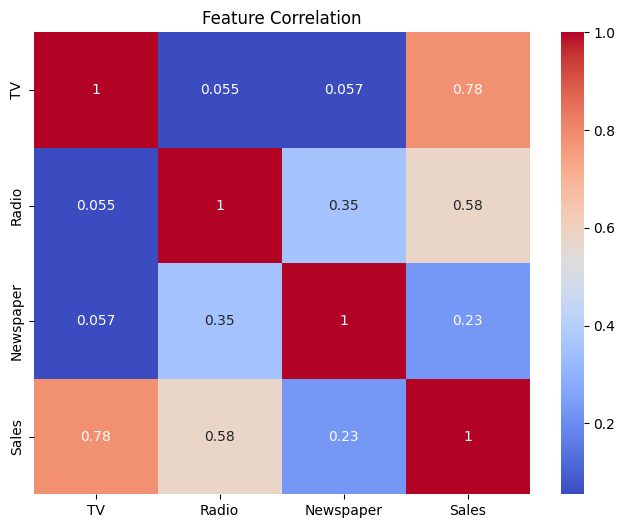

In [30]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

## **Prepare Data for Machine Learning**

In [31]:
X = df[['TV','Radio','Newspaper']]
y = df['Sales']

## **Train-Test Split**

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## **Train Machine Learning Model**

In [33]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

## **Make Predictions**

In [34]:
predictions = model.predict(X_test)

## **Model Evaluation**

In [35]:
print("MAE:", mean_absolute_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))

MAE: 1.4607567168117603
R2 Score: 0.899438024100912


### **Actual vs Predicted Visualization**

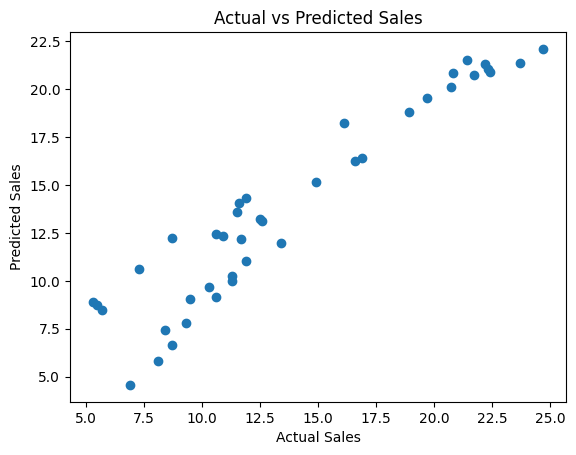

In [36]:
plt.scatter(y_test, predictions)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

## **Conclusion**

A machine learning model was developed to predict product sales based on advertising budgets for TV, radio, and newspaper. Linear regression was used to model the relationship between advertising spending and sales, providing insights into which advertising channels contribute most to sales growth.